# 01: Data Cleaning and Network Construction

This notebook loads one month of flight data, cleans airport coordinates and
constructs domestic flight networks for four countries:
**USA, China, United Kingdom and Australia**.

Each country's domestic flights are modelled as an undirected weighted graph
where airports are nodes and flights are edges.

In [1]:
import sys
sys.path.insert(0, '..')

import matplotlib.pyplot as plt
from src.data_preprocessing import (
    load_data, check_missing_codes, correct_coordinates,
    get_domestic_flights, merge_coordinates
)
from src.visualisation import plot_network_map

## Load and inspect data

In [2]:
airports, flights = load_data('../data/Airports.csv', '../data/Flight Data.xlsx')

print(f'Airports: {airports.shape}')
print(f'Flights:  {flights.shape}')
print(f'\nMissing values (airports):\n{airports.isna().sum()}')
print(f'\nCoordinate summary:\n{airports[["Lat", "Lon"]].describe()}')

Airports: (9033, 5)
Flights:  (60470, 7)

Missing values (airports):
id         0
label      0
country    0
Lat        0
Lon        0
dtype: int64

Coordinate summary:
               Lat          Lon
count  9033.000000  9033.000000
mean     21.395779     1.495902
std      28.947515    95.180262
min     -54.933302  -178.150000
25%      -3.043611   -80.266667
50%      28.000000     5.151667
75%      44.475798    89.050000
max      82.500000   179.883333


In [3]:
missing = check_missing_codes(airports, flights)
print(f"Airport codes in flights but not in airports table: {missing['total_missing']}")

Airport codes in flights but not in airports table: 48


## Coordinate correction

Some airports have incorrect coordinates in the raw data:
Australia airports recorded with positive latitude are corrected to negative values because they should be in the southern hemisphere.
For the USA, eight airports with known incorrect positions are manually fixed.

Only coordinates change. All network connections are preserved.

In [4]:
airports = correct_coordinates(airports)

corrected_count = airports['is_corrected'].sum()
print(f'Total airports corrected: {corrected_count}')

Total airports corrected: 13


## Network statistics

In [5]:
import pandas as pd

countries = ['USA', 'China', 'United Kingdom', 'Australia']
stats = []

for c in countries:
    df_c = get_domestic_flights(flights, c)
    nodes = set(df_c['Source']).union(set(df_c['Target']))
    stats.append({'Country': c, 'Domestic flights': len(df_c), 'Unique airports': len(nodes)})

pd.DataFrame(stats)

,Country,Domestic flights,Unique airports
0,USA,13263,663
1,China,2602,110
2,United Kingdom,638,60
3,Australia,1043,156


## Geospatial visualisation (cleaned coordinates)

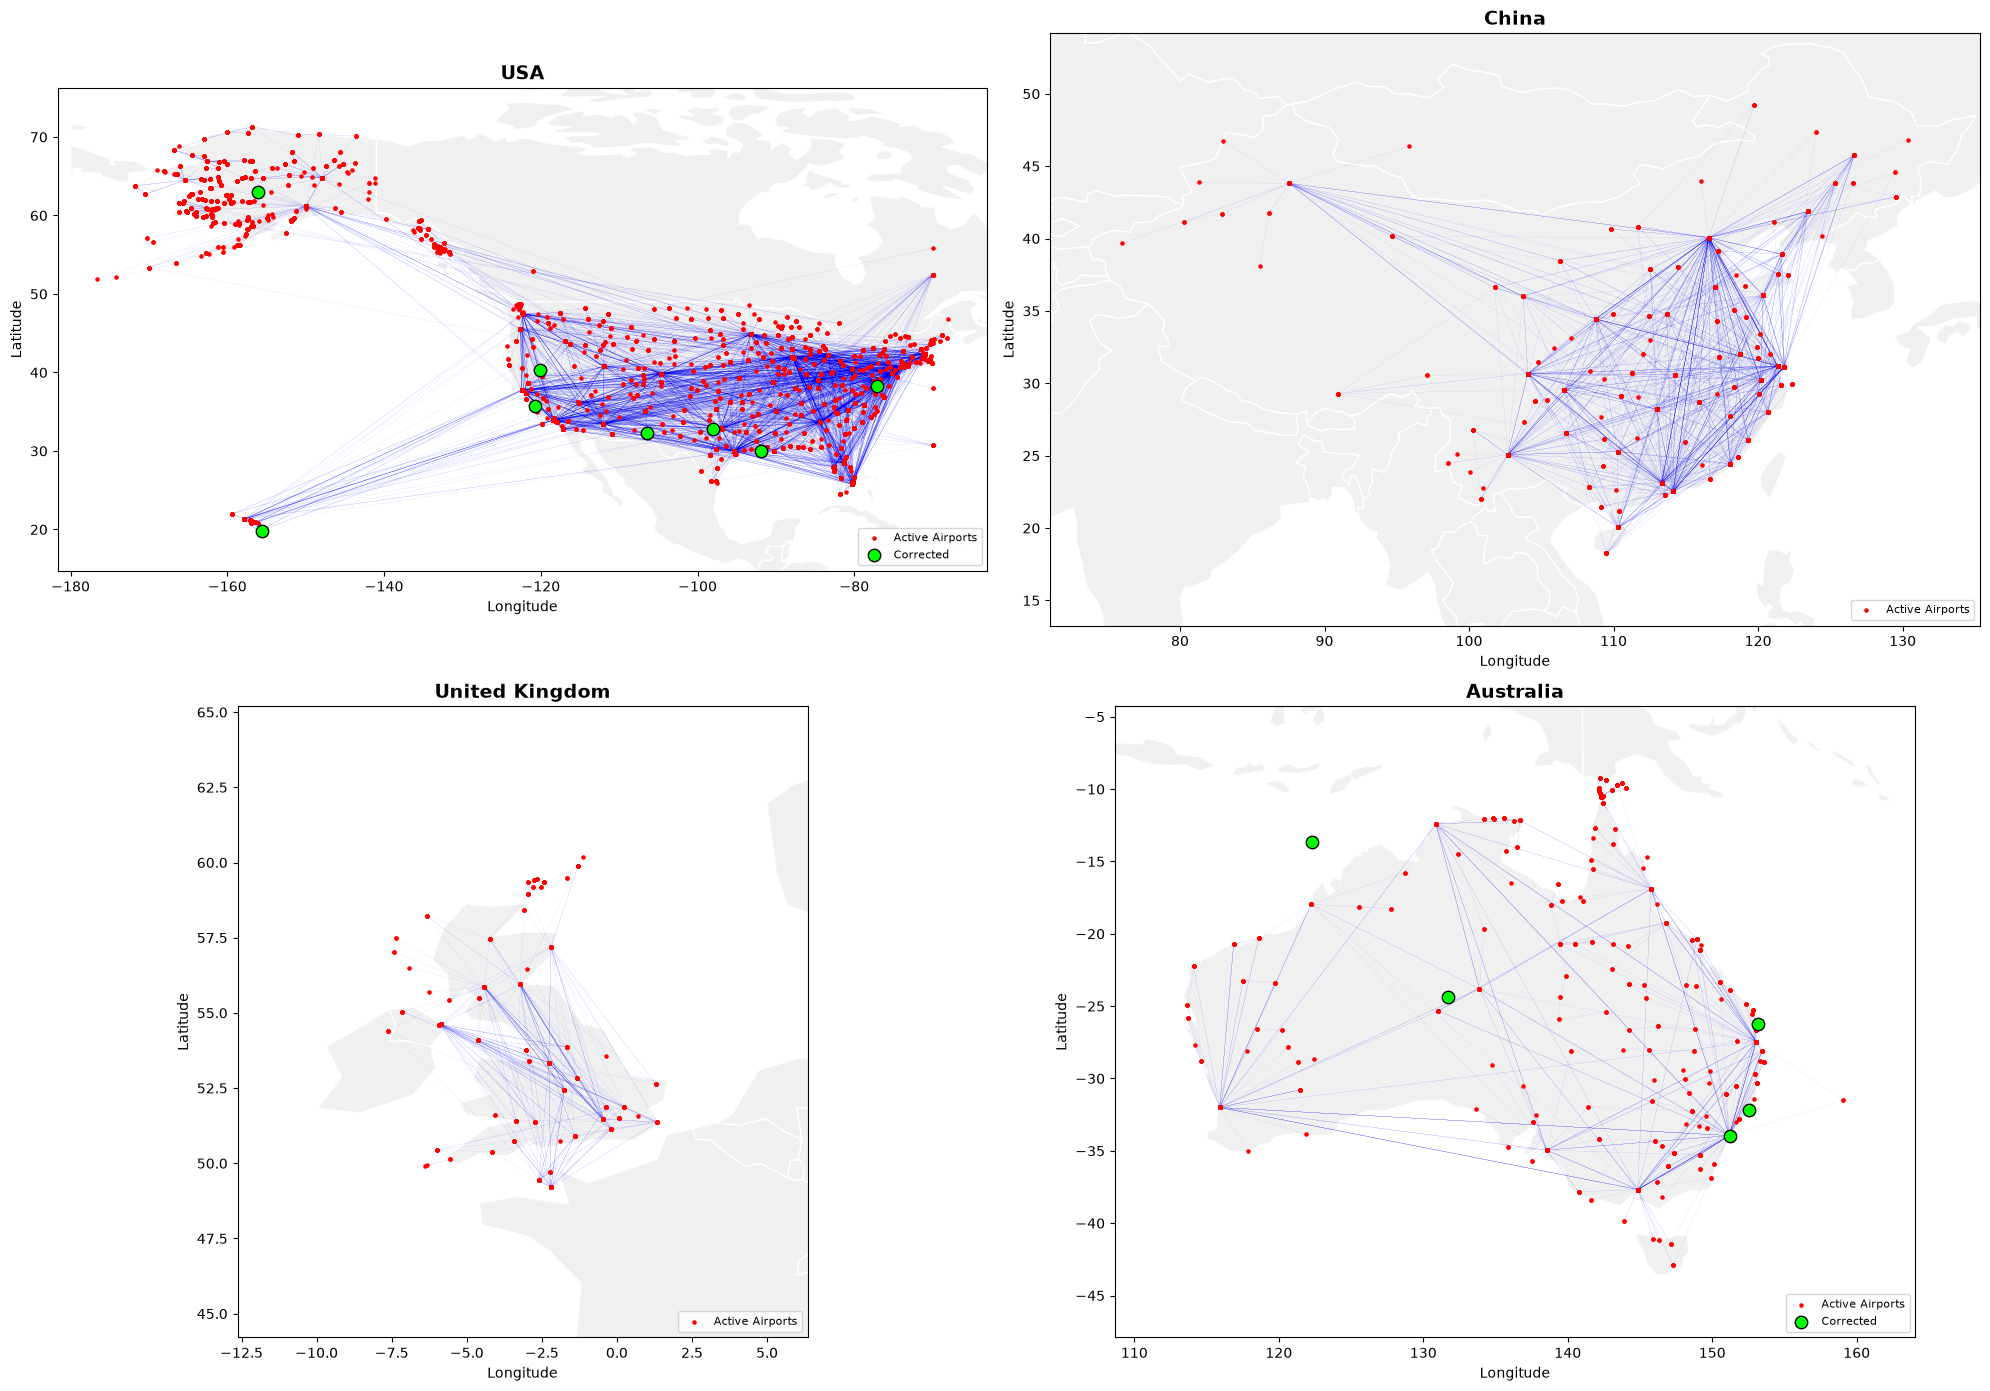

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(20, 14))

for idx, country in enumerate(countries):
    ax = axes[idx // 2, idx % 2]
    dom = get_domestic_flights(flights, country)
    merged = merge_coordinates(dom, airports)
    plot_network_map(merged, airports, country, ax)

plt.tight_layout()
plt.savefig('../figures/cleaned_network_maps.png', dpi=150, bbox_inches='tight')
plt.show()